<a href="https://www.kaggle.com/code/vedikagupta0/using-xgboost-for-churn-pred-0-83?scriptVersionId=304469751" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    accuracy_score
)
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
df_og = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
df2 = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')
tf = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

In [37]:
df_og.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [38]:
df2.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [39]:
id_col = ['id', 'customerID']

In [40]:
df_og.describe(include='object')

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Female,Yes,No,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,No
freq,298738,309554,414362,557893,283384,272386,289474,250083,247377,288571,240301,241435,298918,365579,215372,460377


In [41]:
df2.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [42]:
df_og.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [43]:
df2.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [44]:
df2.shape

(7043, 21)

In [45]:
df_og.shape

(594194, 21)

In [46]:
df = pd.concat([df_og, df2], axis=0)

In [47]:
df.drop(columns=id_col, inplace=True)

In [48]:
df.shape

(601237, 20)

#### 1. No null values are observed.
#### 2. Imbalance is observed in PhoneService, SeniorCitizen and Dependents.
#### SOL: added rarity factor.
#### 3. TotalCharges is skewed probably.
#### SOL: log can be used.
#### 4. Churn i.e. Target column is facing major imbalance.
#### SOL: we can use stratified splitting
#### 5. StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity and InternetService has some weird pattern for NO/ No internet, which can be a useful insight for our modeling.
#### SOL: added something for them.

In [49]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', 0).astype(float)

In [50]:
cat_cols = df.describe(include='object').columns[:-1]

In [51]:
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col])
    df_og[col] = le.transform(df_og[col])
    tf[col] = le.transform(tf[col])
    
    encoders[col] = le
    
    # mapping: original -> encoded
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col} mapping:")
    print(mapping)
    print("-" * 40)

gender mapping:
{'Female': np.int64(0), 'Male': np.int64(1)}
----------------------------------------
Partner mapping:
{'No': np.int64(0), 'Yes': np.int64(1)}
----------------------------------------
Dependents mapping:
{'No': np.int64(0), 'Yes': np.int64(1)}
----------------------------------------
PhoneService mapping:
{'No': np.int64(0), 'Yes': np.int64(1)}
----------------------------------------
MultipleLines mapping:
{'No': np.int64(0), 'No phone service': np.int64(1), 'Yes': np.int64(2)}
----------------------------------------
InternetService mapping:
{'DSL': np.int64(0), 'Fiber optic': np.int64(1), 'No': np.int64(2)}
----------------------------------------
OnlineSecurity mapping:
{'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
----------------------------------------
OnlineBackup mapping:
{'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
----------------------------------------
DeviceProtection mapping:
{'No': np.int64(0),

In [52]:
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})
df_og['Churn'] = df_og['Churn'].map({'No':0, 'Yes':1})

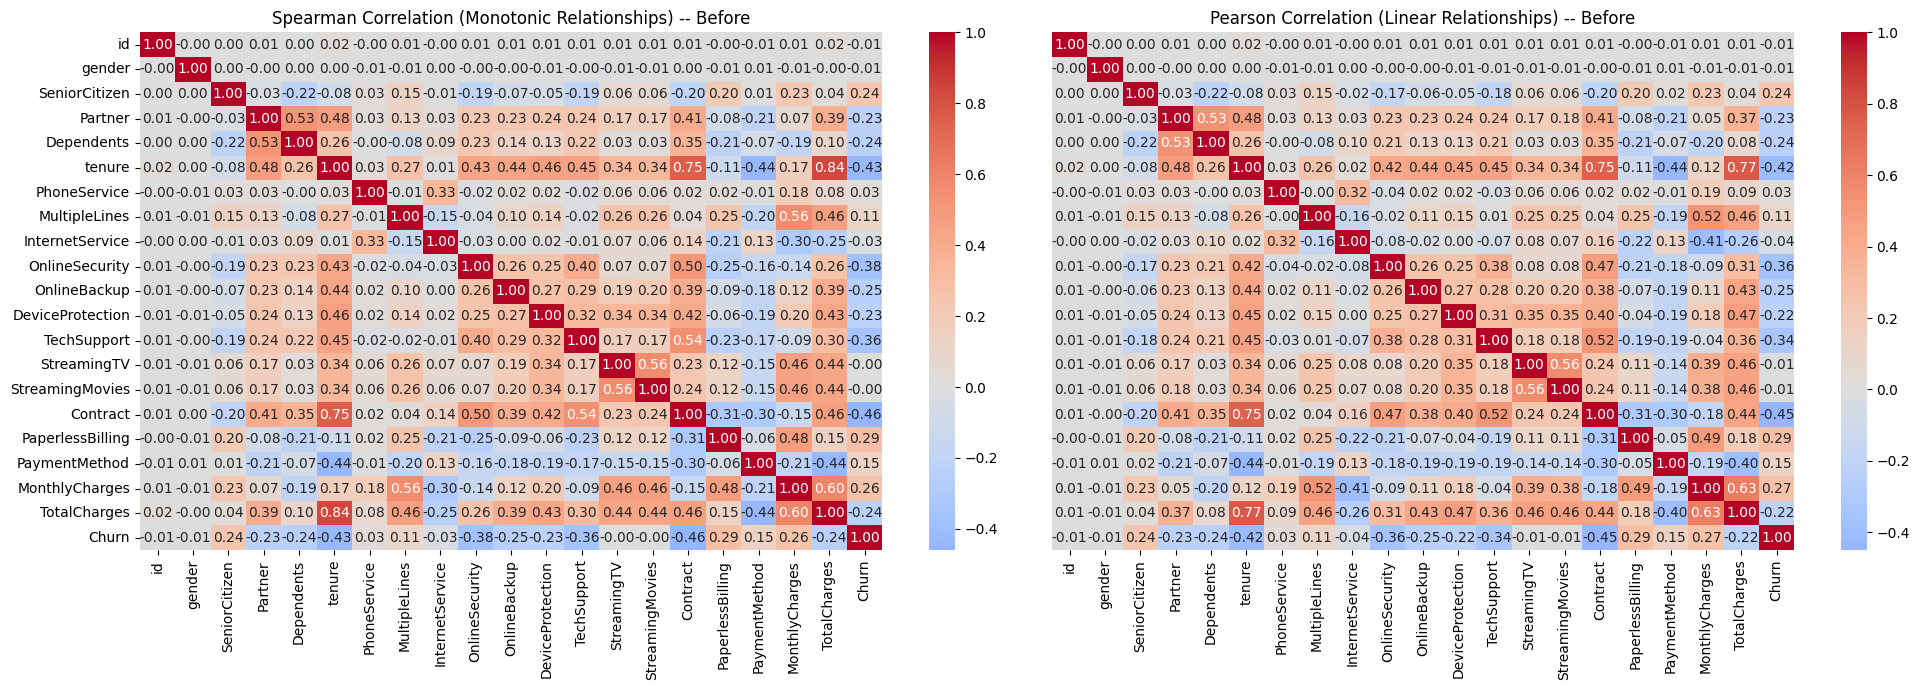

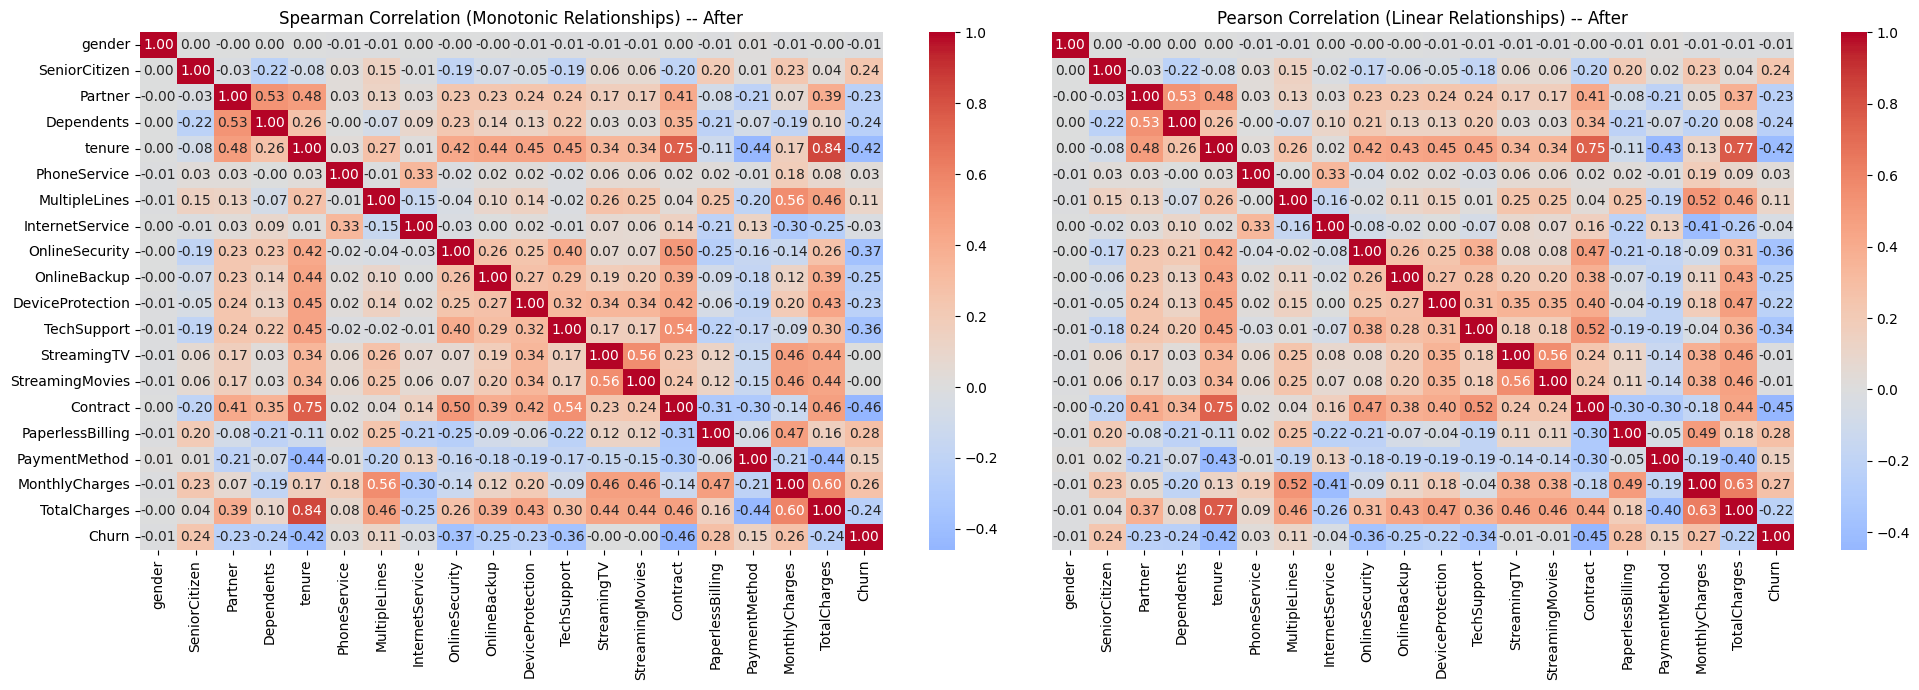

In [53]:
# correlations
spearman_corr = df_og.corr(method="spearman")
kendall_corr  = df_og.corr(method="pearson")

# one row, two columns
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Spearman
sns.heatmap(
    spearman_corr.round(2),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[0]
)
axes[0].set_title("Spearman Correlation (Monotonic Relationships) -- Before")

# Pearson
sns.heatmap(
    kendall_corr.round(2),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[1],
    yticklabels=False
)
axes[1].set_title("Pearson Correlation (Linear Relationships) -- Before")

plt.tight_layout()
plt.show()
# correlations
spearman_corr = df.corr(method="spearman")
kendall_corr  = df.corr(method="pearson")

# one row, two columns
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Spearman
sns.heatmap(
    spearman_corr.round(2),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[0]
)
axes[0].set_title("Spearman Correlation (Monotonic Relationships) -- After")

# Pearson
sns.heatmap(
    kendall_corr.round(2),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[1],
    yticklabels=False
)
axes[1].set_title("Pearson Correlation (Linear Relationships) -- After")

plt.tight_layout()
plt.show()

In [54]:
cols = ['StreamingMovies', 'StreamingTV', 'TechSupport',
        'DeviceProtection', 'OnlineBackup', 'OnlineSecurity']

mask = (df[cols] == 1).all(axis=1)
filtered_df = df[mask]
filtered_df.shape

(142253, 20)

In [55]:
100 - ((df.shape[0] - 140727)/ df.shape[0])*100

23.40624412669213

In [56]:
df.duplicated().sum()

np.int64(22)

In [57]:
df.drop_duplicates(inplace=True)

In [58]:
df['dominance_of_nointernetservice'] = (df[cols] == 1).all(axis=1)
tf['dominance_of_nointernetservice'] = (tf[cols] == 1).all(axis=1)

In [59]:
df.dominance_of_nointernetservice.value_counts()

dominance_of_nointernetservice
False    458976
True     142239
Name: count, dtype: int64

In [60]:
# n = len(df.columns)
# ncols = 3
# nrows = math.ceil(n / ncols)

# # violin plots in grid
# fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
# axes = axes.flatten()

# for i, col in enumerate(df.columns):
#     sns.violinplot(y=df[col], ax=axes[i])
#     axes[i].set_title(col)

# # remove empty axes
# for j in range(i+1, len(axes)):
#     fig.delaxes(axes[j])

# plt.tight_layout()
# plt.show()

In [61]:
cols = ['dominance_of_nointernetservice', 'PaperlessBilling',
        'PhoneService', 'Dependents', 'SeniorCitizen']

pattern_map = {
    'dominance_of_nointernetservice': 1,
    'PaperlessBilling': 0,
    'PhoneService': 0,
    'Dependents': 1,
    'SeniorCitizen': 1
}

# count matches
df['rarity_factor'] = sum((df[col] == val).astype(int) for col, val in pattern_map.items())
tf['rarity_factor'] = sum((tf[col] == val).astype(int) for col, val in pattern_map.items())

# scale to 0–5 (already 0–len(cols), so normalize)
df['rarity_factor'] = 5 * df['rarity_factor'] / len(cols)
tf['rarity_factor'] = 5 * tf['rarity_factor'] / len(cols)

In [62]:
df.rarity_factor.value_counts()

rarity_factor
1.0    210985
0.0    197547
2.0    127535
3.0     65068
4.0        80
Name: count, dtype: int64

In [63]:
cols = ['TotalCharges', 'MonthlyCharges', 'tenure']

def add_features(d):
        # log transform (handle zeros)
    for c in cols:
        d[f'{c}_log'] = np.log1p(d[c])
    
        # row-wise variance across the three columns
        d[f'{c}_var'] = np.var(d[c])
        
    return d

df_og = add_features(df_og)
df    = add_features(df)
tf    = add_features(tf)

In [64]:
df.Churn.value_counts()

Churn
0    465541
1    135674
Name: count, dtype: int64

In [65]:
df_0 = df[df['Churn'] == 0]
df_1 = df[df['Churn'] == 1]

df_0_down = resample(
    df_0,
    replace=False,
    n_samples=150000,
    random_state=42
)

df = pd.concat([df_0_down, df_1])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.Churn.value_counts()

Churn
0    150000
1    135674
Name: count, dtype: int64

In [66]:
target_col = 'Churn'

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)


=== SUMMARY METRICS ===
Train Accuracy: 0.8378
Test Accuracy: 0.8347
Train F1: 0.8356
Test F1: 0.8325
Train ROC-AUC: 0.9166
Test ROC-AUC: 0.9144

=== CLASSIFICATION REPORT (TEST) ===
              precision    recall  f1-score   support

           0       0.87      0.81      0.84     22500
           1       0.80      0.86      0.83     20352

    accuracy                           0.83     42852
   macro avg       0.84      0.84      0.83     42852
weighted avg       0.84      0.83      0.83     42852



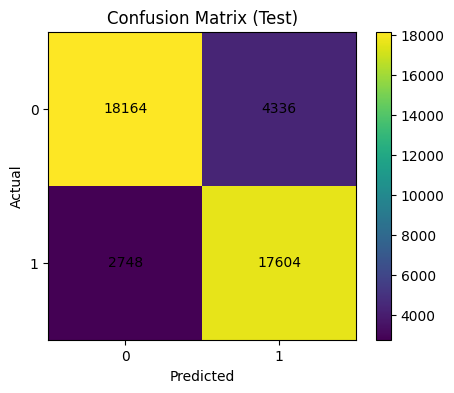

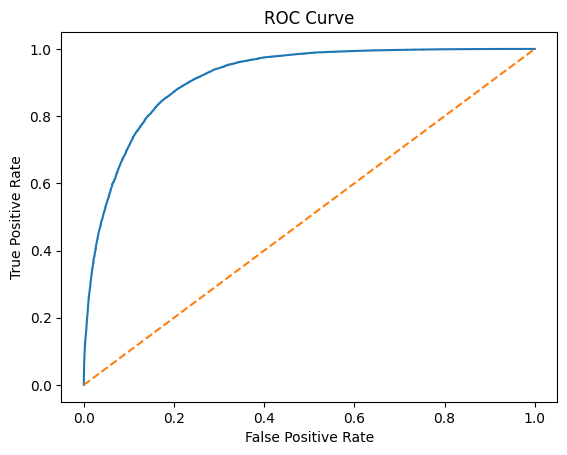

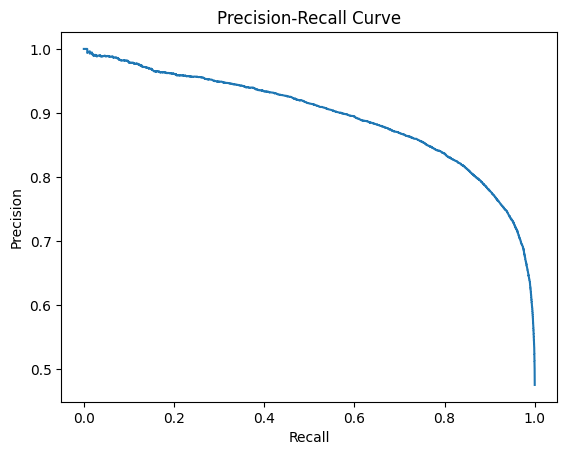


=== TOP FEATURES ===
Contract                          0.622182
TechSupport                       0.069838
OnlineSecurity                    0.065434
MonthlyCharges                    0.041931
PaymentMethod                     0.032026
tenure                            0.026636
InternetService                   0.023308
SeniorCitizen                     0.022552
PaperlessBilling                  0.020588
Dependents                        0.015414
rarity_factor                     0.010731
OnlineBackup                      0.010564
StreamingTV                       0.008906
MultipleLines                     0.007813
StreamingMovies                   0.007447
PhoneService                      0.006820
TotalCharges                      0.003618
DeviceProtection                  0.002211
Partner                           0.001123
gender                            0.000857
dominance_of_nointernetservice    0.000000
TotalCharges_log                  0.000000
TotalCharges_var                

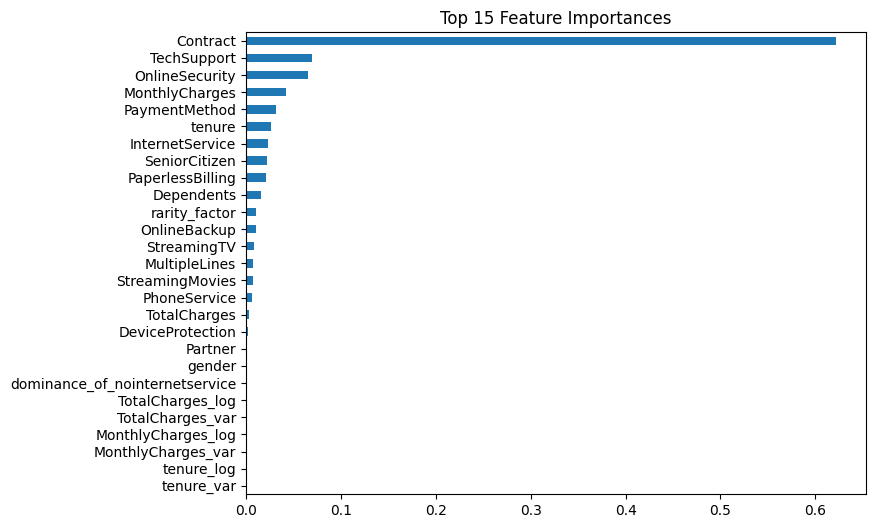

In [67]:
# model
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,   max_depth=5,
    random_state=42,
    eval_metric="logloss",
)

xgb.fit(X_train, y_train)

#preds
train_preds = xgb.predict(X_train)
test_preds  = xgb.predict(X_test)

train_probs = xgb.predict_proba(X_train)[:, 1]
test_probs  = xgb.predict_proba(X_test)[:, 1]

#metrics
metrics = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Test Accuracy": accuracy_score(y_test, test_preds),
    
    "Train F1": f1_score(y_train, train_preds),
    "Test F1": f1_score(y_test, test_preds),
    
    "Train ROC-AUC": roc_auc_score(y_train, train_probs),
    "Test ROC-AUC": roc_auc_score(y_test, test_probs)
}

print("=== SUMMARY METRICS ===")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

#report
print("\n=== CLASSIFICATION REPORT (TEST) ===")
print(classification_report(y_test, test_preds))


cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix (Test)")
plt.colorbar()
plt.xticks([0,1])
plt.yticks([0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

# roc auc curve
fpr, tpr, _ = roc_curve(y_test, test_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# prec-recall curve
prec, rec, _ = precision_recall_curve(y_test, test_probs)

plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# feat importance
importances = xgb.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns)\
             .sort_values(ascending=False)

print("\n=== TOP FEATURES ===")
print(feat_imp)

# plot feature importance
plt.figure(figsize=(8,6))
feat_imp.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.show()

In [68]:
tf_id = tf.pop('id')

In [69]:
submission_xgb = pd.DataFrame({
    'id':tf_id,
    'Churn': pd.Series(xgb.predict(tf))
})
submission_xgb.to_csv('xgb_churn_predictions.csv', index=False)
